# Modify dataset from Yulara Solar System 

In [1]:
import pandas as pd
root = '/home/brakine/VMD_STL_Parallel_TimesNet_BiLSTM_POWERFORECASTING/'
Dataset = pd.read_csv(root + 'data/Yulara/dataset_Laundry.csv').drop(index=0)
assert "timestamp" in Dataset.columns, "'timestamp' column doesn't exist"
Dataset["timestamp"] = pd.to_datetime(Dataset["timestamp"])
df = Dataset.sort_values("timestamp").set_index("timestamp")
df.head()

,Current_Phase_Average_Mean,Active_Energy_Delivered_Received,Active_Power,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation,Pyranometer_1,Temperature_Probe_1,Temperature_Probe_2
timestamp,,,,,,,,,,,,,,
2016-04-02 08:05:00,98.666786,55954.062500,67.071571,1.136667,20.156666,210.748169,163.733337,0.0,2.0,960.053345,0.0,99999.898438,39.524975,39.627743
2016-04-02 08:10:00,109.622101,55960.285156,74.660179,1.340000,20.883333,230.146912,171.433334,0.0,2.7,960.123291,0.0,99999.898438,58.417439,40.284981
2016-04-02 08:15:00,119.205070,55967.062500,81.345879,2.210000,21.663334,248.186584,168.033340,0.0,3.8,960.156677,0.0,99999.898438,40.777805,40.940514
2016-04-02 08:20:00,130.043732,55974.468750,88.874390,1.996667,22.350000,267.595856,178.666672,0.0,3.7,960.256653,0.0,99999.898438,59.515484,41.481670
2016-04-02 08:25:00,139.673813,55982.437500,95.615356,2.193333,22.760000,286.561249,172.466660,0.0,4.3,960.299988,0.0,99999.898438,41.786392,42.088570


## Pre-processing

In [2]:
# Resample the data to 15-minute intervals
df_15 = df.asfreq('15min') 
df_15

,Current_Phase_Average_Mean,Active_Energy_Delivered_Received,Active_Power,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation,Pyranometer_1,Temperature_Probe_1,Temperature_Probe_2
timestamp,,,,,,,,,,,,,,
2016-04-02 08:05:00,98.666786,5.595406e+04,67.071571,1.136667,20.156666,210.748169,163.733337,0.0,2.0,960.053345,0.0,99999.898438,39.524975,39.627743
2016-04-02 08:20:00,130.043732,5.597447e+04,88.874390,1.996667,22.350000,267.595856,178.666672,0.0,3.7,960.256653,0.0,99999.898438,59.515484,41.481670
2016-04-02 08:35:00,161.449417,5.600034e+04,111.072205,2.676667,23.323334,331.059814,164.833328,0.0,4.7,960.413330,0.0,99999.898438,42.977493,43.468781
2016-04-02 08:50:00,190.423676,5.603151e+04,131.054596,2.900000,23.833332,390.291138,157.800003,0.0,4.7,960.716675,0.0,99999.898438,62.742321,45.305721
2016-04-02 09:05:00,215.067612,5.606701e+04,148.134872,3.120000,24.593334,442.589386,145.933334,0.0,5.0,960.799988,0.0,99999.898438,46.109856,47.226147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-25 07:05:00,1.415448,4.750246e+06,-0.057894,0.296667,11.376666,-0.089317,131.066666,0.0,0.5,955.400024,0.0,-0.096918,33.798031,33.860275
2025-05-25 07:20:00,1.479980,4.750246e+06,-0.041862,0.336667,11.600000,0.605174,294.500000,0.0,0.5,955.596619,0.0,0.581371,33.688885,33.784473
2025-05-25 07:35:00,5.361976,4.750246e+06,0.674135,0.636667,11.700000,7.800238,237.500000,0.0,1.1,955.503357,0.0,6.847255,33.804695,33.885284


In [3]:
# masking day values
mask = (df_15.index.hour >= 7) & (df_15.index.hour < 19)
day_dataset = df_15[mask]
day_dataset

,Current_Phase_Average_Mean,Active_Energy_Delivered_Received,Active_Power,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation,Pyranometer_1,Temperature_Probe_1,Temperature_Probe_2
timestamp,,,,,,,,,,,,,,
2016-04-02 08:05:00,98.666786,5.595406e+04,67.071571,1.136667,20.156666,210.748169,163.733337,0.0,2.0,960.053345,0.0,99999.898438,39.524975,39.627743
2016-04-02 08:20:00,130.043732,5.597447e+04,88.874390,1.996667,22.350000,267.595856,178.666672,0.0,3.7,960.256653,0.0,99999.898438,59.515484,41.481670
2016-04-02 08:35:00,161.449417,5.600034e+04,111.072205,2.676667,23.323334,331.059814,164.833328,0.0,4.7,960.413330,0.0,99999.898438,42.977493,43.468781
2016-04-02 08:50:00,190.423676,5.603151e+04,131.054596,2.900000,23.833332,390.291138,157.800003,0.0,4.7,960.716675,0.0,99999.898438,62.742321,45.305721
2016-04-02 09:05:00,215.067612,5.606701e+04,148.134872,3.120000,24.593334,442.589386,145.933334,0.0,5.0,960.799988,0.0,99999.898438,46.109856,47.226147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-25 07:05:00,1.415448,4.750246e+06,-0.057894,0.296667,11.376666,-0.089317,131.066666,0.0,0.5,955.400024,0.0,-0.096918,33.798031,33.860275
2025-05-25 07:20:00,1.479980,4.750246e+06,-0.041862,0.336667,11.600000,0.605174,294.500000,0.0,0.5,955.596619,0.0,0.581371,33.688885,33.784473
2025-05-25 07:35:00,5.361976,4.750246e+06,0.674135,0.636667,11.700000,7.800238,237.500000,0.0,1.1,955.503357,0.0,6.847255,33.804695,33.885284


In [4]:
# Only between 2017-2019
day_dataset = day_dataset.loc['2017-01-01 07:00:00':'2019-12-31 18:55:00']
day_dataset

,Current_Phase_Average_Mean,Active_Energy_Delivered_Received,Active_Power,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation,Pyranometer_1,Temperature_Probe_1,Temperature_Probe_2
timestamp,,,,,,,,,,,,,,
2017-01-01 07:05:00,48.492699,3.713214e+05,31.227783,0.893333,23.389999,148.406616,250.166672,0.0,1.9,950.156677,0.0,123.068008,40.705532,40.482582
2017-01-01 07:20:00,58.992954,3.713303e+05,38.083618,1.216667,24.359999,138.583115,234.300003,0.0,2.1,950.346680,0.0,124.797905,42.008755,41.887486
2017-01-01 07:35:00,63.086151,3.713403e+05,40.624355,1.320000,24.889999,144.925125,214.333328,0.0,2.6,950.693359,0.0,133.914673,42.350296,42.322987
2017-01-01 07:50:00,68.040039,3.713511e+05,43.877464,2.370000,25.299999,161.897522,219.733337,0.0,4.7,950.869995,0.0,149.058136,42.636951,42.713326
2017-01-01 08:05:00,83.128525,3.713633e+05,53.817268,1.833333,25.340000,180.196014,219.166672,0.0,4.6,951.099976,0.0,169.083633,42.815826,42.899017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 17:50:00,96.112434,2.281390e+06,63.349468,1.900000,38.629997,323.046692,108.733330,0.0,3.6,949.599976,0.0,288.603821,55.188206,54.248772
2019-12-31 18:05:00,73.802200,2.281404e+06,48.360943,2.246667,38.276665,263.989166,146.233337,0.0,5.3,949.700012,0.0,230.848785,53.083076,52.608994
2019-12-31 18:20:00,52.968567,2.281414e+06,34.287899,2.906667,38.033333,206.388672,144.300003,0.0,4.8,949.863342,0.0,175.887955,51.626602,51.116817


In [14]:
# Modify DF (reference article downloads data 1 year before I trained the model)
day_dataset['Active_Energy_Received'] = day_dataset['Active_Energy_Delivered_Received'].diff()

# Drop unnecessary columns (not employed in reference article)
transformed_df = day_dataset.drop(columns=["Hail_Accumulation", "Weather_Daily_Rainfall", 
                                        "Wind_Direction", "Air_Pressure",
                                        "Active_Energy_Delivered_Received",
                                        "Current_Phase_Average_Mean"])

/tmp/ipykernel_16378/3270213894.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_dataset['Active_Energy_Received'] = day_dataset['Active_Energy_Delivered_Received'].diff()


In [15]:
# Replace negative values
transformed_df['Active_Power'] = transformed_df['Active_Power'].clip(lower=0)
transformed_df['Pyranometer_1'] = transformed_df['Pyranometer_1'].clip(lower=0)
transformed_df['Global_Horizontal_Radiation'] = transformed_df['Global_Horizontal_Radiation'].clip(lower=0)

# Nan values treatment
df_interp = transformed_df.copy()
df_interp = df_interp.interpolate(method="linear",  limit_direction="both") # timestamp como index 
df_interp.isna().mean().sort_values(ascending=False)

Active_Power                   0.0
Wind_Speed                     0.0
Weather_Temperature_Celsius    0.0
Global_Horizontal_Radiation    0.0
Max_Wind_Speed                 0.0
Pyranometer_1                  0.0
Temperature_Probe_1            0.0
Temperature_Probe_2            0.0
Active_Energy_Received         0.0
dtype: float64

In [16]:
# Outliers values treatment
import numpy as np

def winsorize_by_zscore(df, columns=None, threshold=3.0, inplace=False):
    """
    Replace outliers (z-score) to mu ± k*sigma (capping).
    
    Params:
    - df: DataFrame 
    - columns: if None, take df.columns
    - threshold: k en |z| > k (commonly 3.0).
    - inplace: if True modify in the same df, else create a copy

    Outputs:
    - df_out: DataFrame post-capping.
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    df_out = df if inplace else df.copy()

    for col in columns:
        s = df_out[col]
        if not np.issubdtype(s.dtype, np.number):
            continue

        mu = s.mean(skipna=True)
        sigma = s.std(ddof=0, skipna=True) 

        lower = mu - threshold * sigma
        upper = mu + threshold * sigma

        before = s.copy()
        df_out[col] = s.clip(lower=lower, upper=upper)

    return df_out

df_final = winsorize_by_zscore(df_interp, columns=None, threshold=3.0)

## Save final processed version

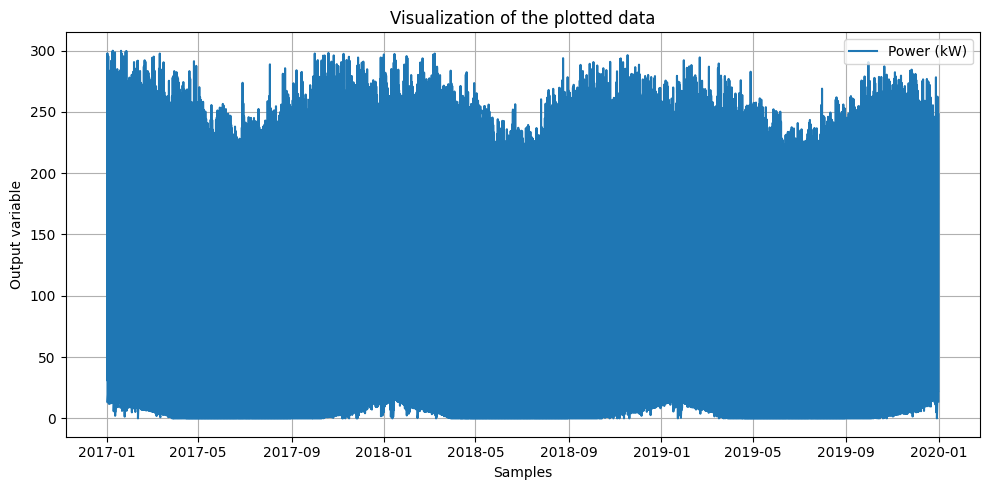

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_final.index, df_final["Active_Power"], label='Power (kW)')
plt.title('Visualization of the plotted data')
plt.xlabel('Samples'); plt.ylabel('Output variable')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
# save resulting dataframe
df_final.to_csv('./data/processed/dataset_Yulara_modified.csv', index=False)